In [2]:
#Clustering (Unsupervised Learning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')#Hides unnecessary  warning meassages

#Set custom styling for plots
sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.dpi']=110
plt.rcParams['figure.figsize']=(10,6)

In [3]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


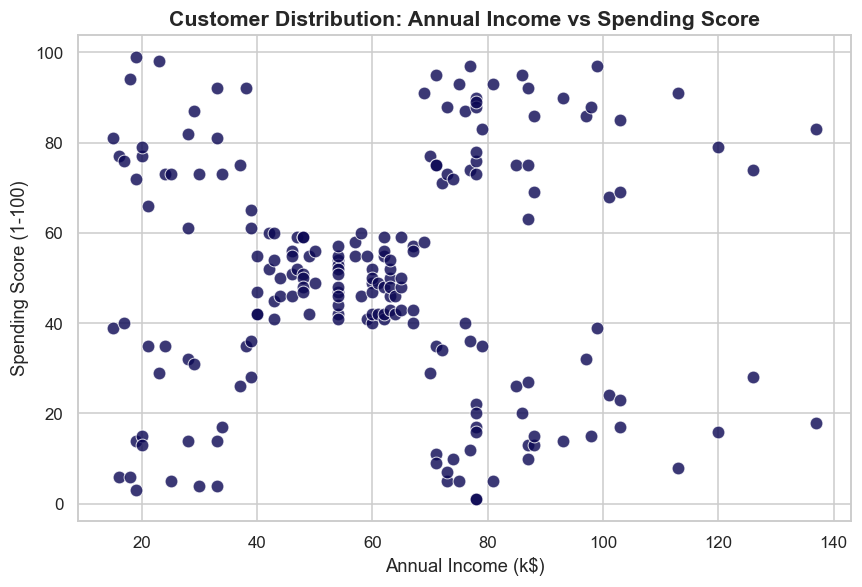

In [4]:
#Scatter Plot to indentify no. of clusters to be formed
plt.figure(figsize=(8,5.5))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',s=70,color="#0a0653",alpha=0.8)
plt.title("Customer Distribution: Annual Income vs Spending Score",fontsize=14,fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

In [5]:
#do scling because of huge value difference in income and spending
x=df[['Annual Income (k$)','Spending Score (1-100)']]
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled_df=pd.DataFrame(x_scaled,columns=x.columns)
print(x_scaled_df)

     Annual Income (k$)  Spending Score (1-100)
0             -1.738999               -0.434801
1             -1.738999                1.195704
2             -1.700830               -1.715913
3             -1.700830                1.040418
4             -1.662660               -0.395980
..                  ...                     ...
195            2.268791                1.118061
196            2.497807               -0.861839
197            2.497807                0.923953
198            2.917671               -1.250054
199            2.917671                1.273347

[200 rows x 2 columns]


In [6]:
#make kmeans model
kmeans=KMeans(n_clusters=5,init='k-means++',n_init=10,random_state=42)
kmeans.fit(x_scaled)
labels=kmeans.labels_#extract cluster assignments(which group each customer belongs to)
centroids_scaled=kmeans.cluster_centers_#extract the positions of 5 centroids
print("Model Training complete")

Model Training complete


Text(0.5, 1.0, 'Mall Customer Segmentation (k=5)')

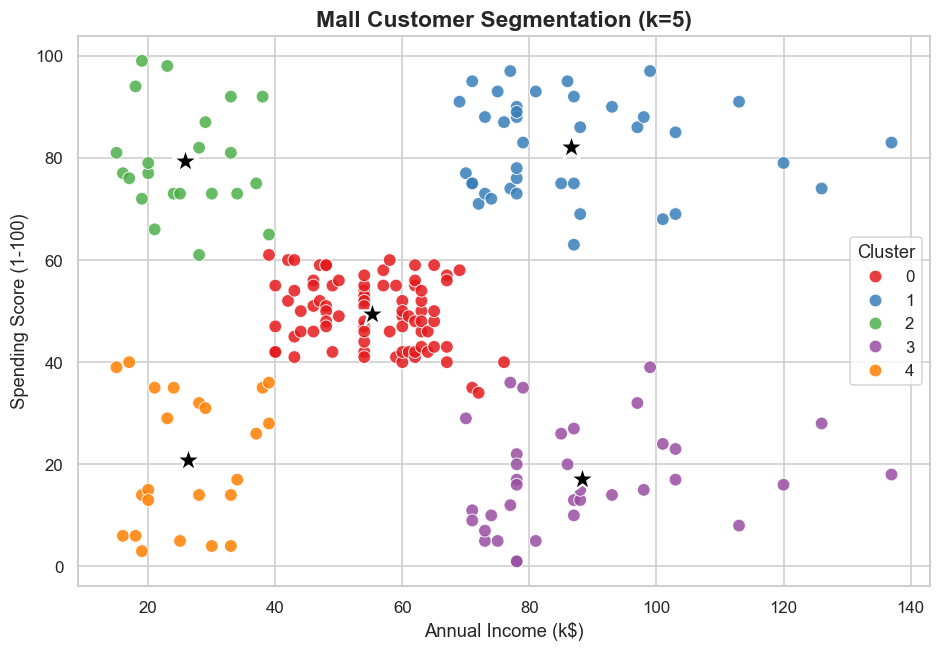

In [7]:
#Position of centroids was of scaled data but we want its pos on original data so inverse transform
centroids_orig=scaler.inverse_transform(centroids_scaled)
#add the cluster labels to our original dataframe as a new column
df['Cluster']=labels
plt.figure(figsize=(10,6.5))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',palette='Set1',s=70,alpha=0.85,edgecolor='w')
#Plot centroids as black stars
plt.scatter(
    centroids_orig[:,0], #x coordinates of centroids
    centroids_orig[:,1], # y coordinates
    color='black',marker='*',s=300,edgecolor='white',linewidth=1.5,label='Centroids (Cluster Centers)'
)
plt.title("Mall Customer Segmentation (k=5)",fontdict={'size':15,'weight':'bold'})